# **Image Filter**
 

*   Mykola Liashuha
*   Jose Gonzalez Lopez



# Introduction
In this work we will see different filters applied to an image and comment their effects after testing them a watching the main changes that happened to the new image after the transformation. In the end, we will comment our final conclusions on the notebook. 


# Imports

In [18]:
import numpy as np #Numpy for calculations
import math #For calculations
import cv2 as cv #For the images
import random #For the salt peper noise
import copy #for copy data

from matplotlib import pyplot as plt #Plots


# Auxiliar functions

In [19]:
'''
Returns the image with salt and peper noise. IMPORTANT: This function was used 
in [1] and we just used the code just to show the effect of the filters.
'''
def add_noise(og_img):
    img=copy.deepcopy(og_img) #We do not want to change img!!!
  
    # Getting the dimensions of the image
    row, col,_ = img.shape
      
    # Randomly pick some pixels in the
    # image for coloring them white
    # Pick a random number between 300 and 10000
    number_of_pixels = random.randint(300, 10000)
    for i in range(number_of_pixels):
        
        # Pick a random y coordinate
        y_coord=random.randint(0, row - 1)
          
        # Pick a random x coordinate
        x_coord=random.randint(0, col - 1)
          
        # Color that pixel to white
        img[y_coord][x_coord] = 255
          
    # Randomly pick some pixels in
    # the image for coloring them black
    # Pick a random number between 300 and 10000
    number_of_pixels = random.randint(300 , 10000)
    for i in range(number_of_pixels):
        
        # Pick a random y coordinate
        y_coord=random.randint(0, row - 1)
          
        # Pick a random x coordinate
        x_coord=random.randint(0, col - 1)
          
        # Color that pixel to black
        img[y_coord][x_coord] = 0
          
    return img

# Original image
Let's first see the original image to which we are going to apply the filters.

Text(0.5, 1.0, 'Orignal Image')

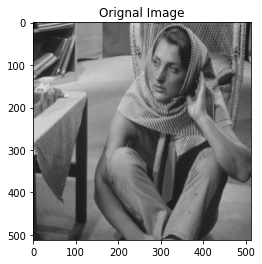

In [20]:
img = cv.imread('barbara.jpg') #Reading
plt.imshow(img) #And plot
plt.title("Orignal Image")

# Gradient Filter
Gradient filters are the ones that will detect the directions of the points that change in intensity quicker. These points will be the edges. To compute them, we will use the derivatives in the two dimensions of the image to detect those edges in the direction of those variables (horizontal edges and vertical edges). The use of getting these gradient images will help us to get the Sobel filter later.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'Gradient X')

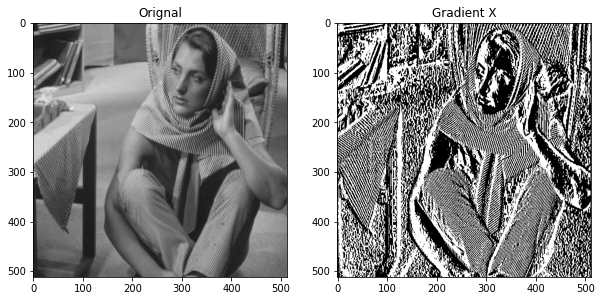

In [21]:
img_gradient_x = cv.Sobel(img,cv.CV_64F,1,0) #The sobel library from cv2 will get us the gradients in the x direction

#And this is to plot the filtered image and the original
fig = plt.figure(figsize=(10, 10))
fig.add_subplot(1, 2, 1)
plt.imshow(img)
plt.title("Orignal")

fig.add_subplot(1, 2, 2)
plt.imshow(img_gradient_x,cmap = 'gray')
plt.title("Gradient X")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


Text(0.5, 1.0, 'Gradient Y')

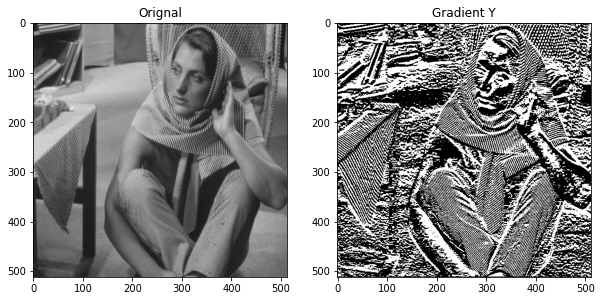

In [22]:
img_gradient_y = cv.Sobel(img,cv.CV_64F,0,1) #The sobel library from cv2 will get us the gradients in the y direction

#And this is to plot the filtered image and the original
fig = plt.figure(figsize=(10, 10))
fig.add_subplot(1, 2, 1)
plt.imshow(img)
plt.title("Orignal")

fig.add_subplot(1, 2, 2)
plt.imshow(img_gradient_y,cmap = 'gray')
plt.title("Gradient Y")

# Sobel Filter
Using both gradients will give us the sobel filter and with this operation, the edges of the original image will be highlited. Computing the magnitude of the gradients will also help us to identify the edges more smoothly and it will also reasure us that the gradient filters were computed correctly.

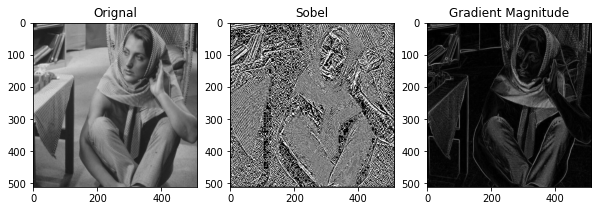

In [27]:
#Sobel
sobel=cv.Sobel(img,cv.CV_64F,1,1)

#Using the gradient magnitude
gradient_magnitude=np.sqrt(img_gradient_x**2+img_gradient_y**2)
gradient_magnitude *= 255.0 / gradient_magnitude.max()
orientation = np.arctan2(img_gradient_y, img_gradient_y) * (180 / np.pi) % 180

#Plot results
fig = plt.figure(figsize=(10, 10))
fig.add_subplot(1, 3, 1)
plt.imshow(img)
plt.title("Orignal")

fig.add_subplot(1, 3, 2)
plt.imshow(sobel.astype('uint8'),cmap="gray_r")
plt.title("Sobel")

fig.add_subplot(1, 3, 3)
plt.imshow(gradient_magnitude.astype('uint8'),cmap="gray_r")
plt.title("Gradient Magnitude")
plt.show()

# Averaging Filter
The average filter is an operation whose main objective is to smooth the image by taking the mean of the neighbour pixels and compute a new value for each position of the photograph. In this case we have used a 3X3 sliding window and and 7X7 window to see the difference between the operations

Text(0.5, 1.0, 'Average 7X7')

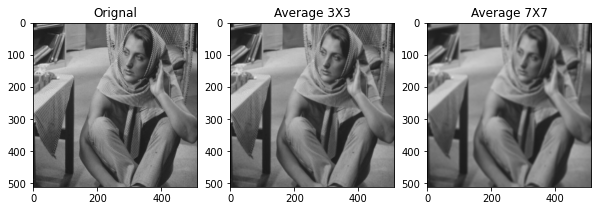

In [24]:
img_avg_33 = cv.blur(src=img,ksize=(3,3)) #Doing average 3x3 kernel
img_avg_77 = cv.blur(src=img,ksize=(7,7)) #Doing average 7x7 kernel

fig = plt.figure(figsize=(10, 10))
fig.add_subplot(1, 3, 1)
plt.imshow(img)
plt.title("Orignal")

fig.add_subplot(1, 3, 2)
plt.imshow(img_avg_33)
plt.title("Average 3X3")

fig.add_subplot(1, 3, 3)
plt.imshow(img_avg_77)
plt.title("Average 7X7")

As we can see, in this case the 9X9 window had a much greater impact than the 3X3. In this cases, this filter seems to be useless to actually help us get a better image or retrieve information like sobel or the gradients. What what if the image was not perfectly computed and had some misinformation or noise? That is where this filter can actually be very useful. Let's apply some noise over the original image [1] and then apply the same operations to see the full potential of these filters.

Text(0.5, 1.0, 'Average 9X9')

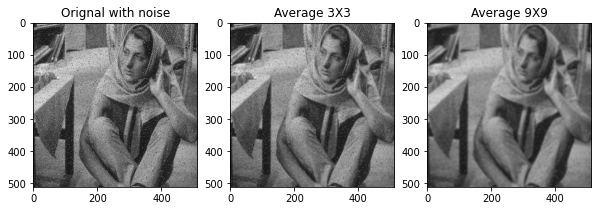

In [25]:
img_noise=add_noise(img)
img_avg_33 = cv.blur(src=img_noise,ksize=(3,3)) #Doing average 3x3 kernel
img_avg_77 = cv.blur(src=img_noise,ksize=(7,7)) #Doing average 9x9 kernel

fig = plt.figure(figsize=(10, 10))
fig.add_subplot(1, 3, 1)
plt.imshow(img_noise)
plt.title("Orignal with noise")

fig.add_subplot(1, 3, 2)
plt.imshow(img_avg_33)
plt.title("Average 3X3")

fig.add_subplot(1, 3, 3)
plt.imshow(img_avg_77)
plt.title("Average 9X9")

# Gaussian Filter

Text(0.5, 1.0, 'Gaussian')

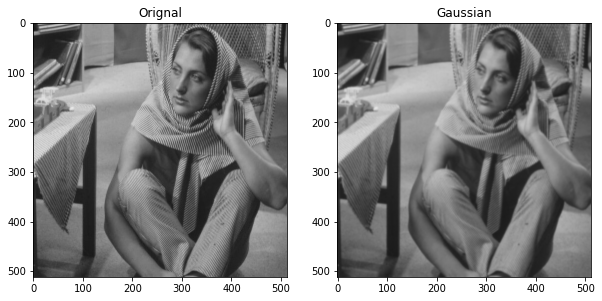

In [26]:
img_gaussian_blur_33 = cv.GaussianBlur(img,(3,3),sigmaX=0)
fig = plt.figure(figsize=(10, 10))
fig.add_subplot(1, 2, 1)
plt.imshow(img)
plt.title("Orignal")

fig.add_subplot(1, 2, 2)
plt.imshow(img_gaussian_blur)
plt.title("Gaussian")

# Conclusions

# References
[1] [Salt and peper code](https://www.geeksforgeeks.org/add-a-salt-and-pepper-noise-to-an-image-with-python/)